In [1]:
!python --version

Python 3.13.15


In [5]:
from pathlib import Path
import csv
import os
import pickle
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import supervision as sv
from dotenv import load_dotenv
from tqdm.notebook import tqdm
from IPython.display import Image, display, Video

load_dotenv()

clip = Path('testclips/clip_20260812_170115.h264')
ground_truth = Path('testclips/clip_20260812_170115_manual_counts.csv')

model_id = 'alan-l-abbott-gmail-com/bikecounter-2-rfdetr-small-t1'
fps = 15.0
conf = 0.4

# from pick_line.py
line_start = sv.Point(1426,1080)
line_end = sv.Point(920,0)

cache = Path('cache')
cache.mkdir(exist_ok=True)

In [6]:
from inference import get_model

model = get_model(model_id=model_id, api_key=os.getenv('ROBOFLOW_API_KEY'))
print('loaded', model_id)

Output()

loaded alan-l-abbott-gmail-com/bikecounter-2-rfdetr-small-t1


2026-08-18 21:43:06.693801 [W:onnxruntime:, coreml_execution_provider.cc:112 GetCapability] CoreMLExecutionProvider::GetCapability, number of partitions supported by CoreML: 103 number of nodes in the graph: 889 number of nodes supported by CoreML: 711


In [7]:
cache_path = cache / f'{clip.stem}_conf{conf}_detections.pkl'

def run_detection(clip_path, conf):
    cap = cv2.VideoCapture(str(clip_path))
    if not cap.isOpened():
        raise SystemExit(f'could not open {clip_path}')

    per_frame = []
    pbar = tqdm(desc='detecting', unit='f')

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        result = model.infer(frame, confidence=conf)[0]
        det = sv.Detections.from_inference(result)

        per_frame.append({
            'xyxy': det.xyxy,
            'confidence': det.confidence,
            'class_id': det.class_id,
        })
        pbar.update(1)

    pbar.close()
    cap.release()
    return per_frame

if cache_path.exists():
    with open(cache_path, 'rb') as f:
        detections_by_frame = pickle.load(f)
    print(f'loaded {len(detections_by_frame)} frames from cache')
else:
    detections_by_frame = run_detection(clip, conf)
    with open(cache_path, 'wb') as f:
        pickle.dump(detections_by_frame, f)
    print(f'detected and cached {len(detections_by_frame)} frames')

detecting: 0f [00:00, ?f/s]

Selected RF-DETR preprocessor implementation=base max_workers=4


detected and cached 13496 frames


In [8]:
counts = [len(d['xyxy']) for d in detections_by_frame]
nonzero = sum(1 for c in counts if c > 0)

print(f'frames: {len(counts)}')
print(f'frames with >=1 detection: {nonzero} ({nonzero/len(counts):.1%})')
print(f'max detections in one frame: {max(counts)}')

confs = [d['confidence'] for d in detections_by_frame
         if d['confidence'] is not None and len(d['confidence'])]
if confs:
    all_conf = np.concatenate(confs)
    print(f'total detections: {len(all_conf)}')
    print(f'confidence: min {all_conf.min():.2f}  '
          f'median {np.median(all_conf):.2f}  max {all_conf.max():.2f}')
else:
    print('no detections at all — check the model and confidence threshold')

frames: 13496
frames with >=1 detection: 1781 (13.2%)
max detections in one frame: 2
total detections: 1863
confidence: min 0.40  median 0.83  max 0.96


In [9]:
def track_and_count(detections_by_frame, start, end, stride=1, fps=fps):
    effective_fps = max(1, int(fps / stride))
    tracker = sv.ByteTrack(frame_rate=effective_fps)
    line_zone = sv.LineZone(start=start, end=end)

    events = []
    tracked_by_frame = {}

    for frame_idx, d in enumerate(detections_by_frame):
        if frame_idx % stride != 0:
            continue

        det = sv.Detections(
            xyxy=d['xyxy'],
            confidence=d['confidence'],
            class_id=d['class_id'],
        )
        det = tracker.update_with_detections(det)
        crossed_in, crossed_out = line_zone.trigger(det)

        if len(det) > 0 and det.tracker_id is not None:
            for i, tid in enumerate(det.tracker_id):
                if crossed_in[i] or crossed_out[i]:
                    events.append({
                        'frame': frame_idx,
                        'seconds': round(frame_idx / fps, 2),
                        'direction': 'IN' if crossed_in[i] else 'OUT',
                        'tracker_id': int(tid),
                    })

        tracked_by_frame[frame_idx] = det

    return events, tracked_by_frame, line_zone


events, tracked, line_zone = track_and_count(
    detections_by_frame, line_start, line_end, stride=1)

print(f'IN:  {line_zone.in_count}')
print(f'OUT: {line_zone.out_count}')
print(f'total events: {len(events)}')

/var/folders/5w/738vvdqd76l8jrmjp79ff2g80000gn/T/ipykernel_52929/228828704.py:3: FutureWarning: The `ByteTrack` was deprecated since v0.28.0. It will be removed in v0.31.0.
  tracker = sv.ByteTrack(frame_rate=effective_fps)


IN:  8
OUT: 19
total events: 27


In [15]:
direction_map = {'IN': 'SB', 'OUT': 'NB'}

gt = pd.read_csv(ground_truth)
pred = pd.DataFrame(events)
if len(pred):
    pred['direction'] = pred['direction'].map(direction_map)

print('ground truth')
print(gt['direction'].value_counts().to_string())
print(f'  total {len(gt)}\n')

print('pipeline')
if len(pred):
    print(pred['direction'].value_counts().to_string())
    print(f'  total {len(pred)}')
else:
    print('  no events')

ground truth
direction
NB    19
SB    11
  total 30

pipeline
direction
NB    19
SB     8
  total 27


In [16]:
tolerance_s = 3.0

def match_events(gt_df, pred_df, tolerance=tolerance_s):
    pool = pred_df.to_dict('records') if len(pred_df) else []
    used = set()
    matched, missed = [], []

    for _, g in gt_df.iterrows():
        best, best_dt = None, None
        for j, p in enumerate(pool):
            if j in used or p['direction'] != g['direction']:
                continue
            dt = abs(p['seconds'] - g['seconds'])
            if dt <= tolerance and (best_dt is None or dt < best_dt):
                best, best_dt = j, dt
        if best is None:
            missed.append(g.to_dict())
        else:
            used.add(best)
            matched.append((g.to_dict(), pool[best], best_dt))

    extra = [p for j, p in enumerate(pool) if j not in used]
    return matched, missed, extra


matched, missed, extra = match_events(gt, pred)

print(f'matched: {len(matched)}')
print(f'missed:  {len(missed)}   (in ground truth, pipeline did not count)')
print(f'extra:   {len(extra)}   (pipeline counted, not in ground truth)')

if missed:
    print('\nMISSED')
    for m in missed:
        print(f"  {m['timestamp']}  {m['direction']}  frame {m['frame']}")

if extra:
    print('\nEXTRA')
    for e in extra:
        print(f"  {e['seconds']:>8.2f}s  {e['direction']}  "
              f"track #{e['tracker_id']}  frame {e['frame']}")

matched: 27
missed:  3   (in ground truth, pipeline did not count)
extra:   0   (pipeline counted, not in ground truth)

MISSED
  00:23.07  SB  frame 346
  09:51.60  SB  frame 8874
  14:56.13  SB  frame 13442


In [17]:
def export_annotated(clip_path, tracked_by_frame, start, end, out_path,
                     stride=1, fps=fps):
    box_ann = sv.BoxAnnotator(thickness=2)
    label_ann = sv.LabelAnnotator(text_scale=0.5)
    trace_ann = sv.TraceAnnotator(trace_length=30)
    line_ann = sv.LineZoneAnnotator(thickness=2, text_scale=0.8)

    # fresh zone so the on-screen totals advance as the video plays
    zone = sv.LineZone(start=start, end=end)

    cap = cv2.VideoCapture(str(clip_path))
    ok, probe = cap.read()
    if not ok:
        raise SystemExit('could not read frames')
    h, w = probe.shape[:2]
    cap.release()

    cap = cv2.VideoCapture(str(clip_path))
    effective_fps = max(1, int(fps / stride))
    writer = cv2.VideoWriter(str(out_path),
                             cv2.VideoWriter_fourcc(*'mp4v'),
                             effective_fps, (w, h))

    idx = -1
    pbar = tqdm(desc='writing', unit='f')
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        idx += 1
        if idx not in tracked_by_frame:
            continue

        det = tracked_by_frame[idx]
        zone.trigger(det)

        out = frame.copy()
        if len(det) > 0:
            out = trace_ann.annotate(scene=out, detections=det)
            out = box_ann.annotate(scene=out, detections=det)
            if det.tracker_id is not None and det.confidence is not None:
                labels = [f'#{t} {c:.2f}'
                          for t, c in zip(det.tracker_id, det.confidence)]
                out = label_ann.annotate(scene=out, detections=det,
                                         labels=labels)
        out = line_ann.annotate(frame=out, line_counter=zone)

        writer.write(out)
        pbar.update(1)

    pbar.close()
    cap.release()
    writer.release()
    print(f'wrote {out_path}')


out_video = Path(f'{clip.stem}_annotated.mp4')
export_annotated(clip, tracked, line_start, line_end, out_video)

writing: 0f [00:00, ?f/s]

wrote clip_20260812_170115_annotated.mp4


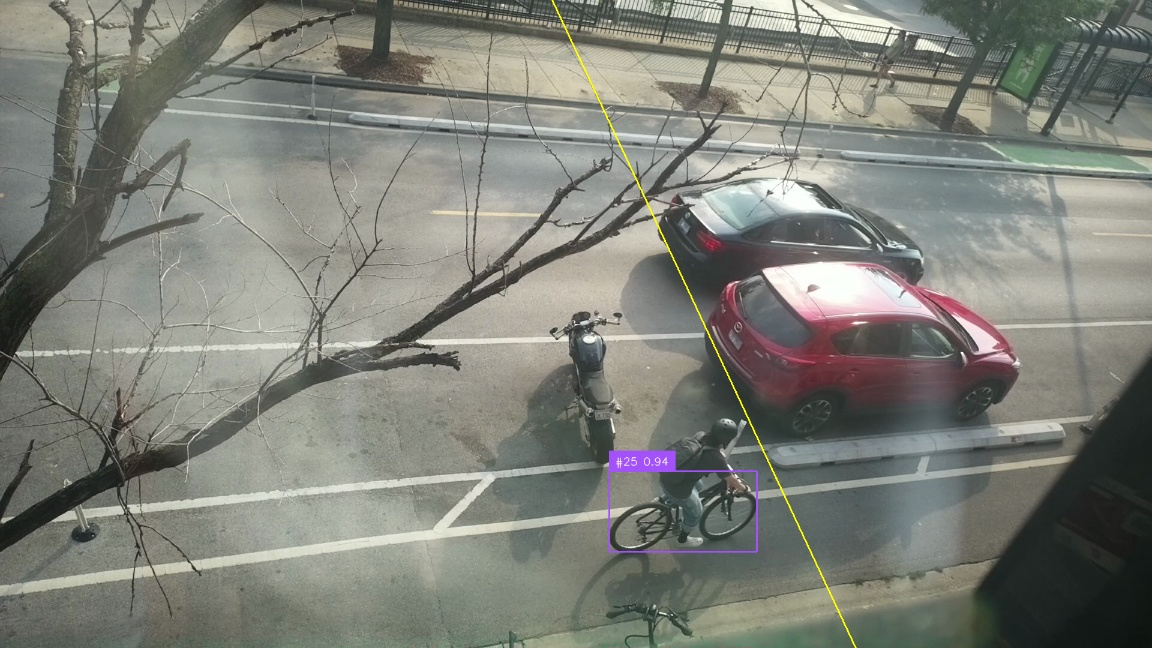

In [13]:
def show_frame(clip_path, frame_number, tracked_by_frame, scale=0.6):
    cap = cv2.VideoCapture(str(clip_path))
    frame = None
    for _ in range(frame_number + 1):
        ok, frame = cap.read()
        if not ok:
            break
    cap.release()
    if frame is None:
        print('could not reach that frame')
        return

    det = tracked_by_frame.get(frame_number)
    out = frame.copy()

    if det is not None and len(det) > 0:
        out = sv.BoxAnnotator(thickness=2).annotate(scene=out, detections=det)
        if det.tracker_id is not None and det.confidence is not None:
            labels = [f'#{t} {c:.2f}'
                      for t, c in zip(det.tracker_id, det.confidence)]
            out = sv.LabelAnnotator(text_scale=0.6).annotate(
                scene=out, detections=det, labels=labels)

    cv2.line(out, (line_start.x, line_start.y),
             (line_end.x, line_end.y), (0, 255, 255), 2)

    out = cv2.resize(out, None, fx=scale, fy=scale)
    _, buf = cv2.imencode('.jpg', out)
    display(Image(data=buf.tobytes()))


# e.g. the NB cluster around 4:33
show_frame(clip, 4103, tracked)

In [14]:
rows = []
for stride in [1, 2, 3, 5]:
    ev, _, lz = track_and_count(detections_by_frame,
                               line_start, line_end, stride=stride)
    rows.append({
        'stride': stride,
        'effective_fps': round(fps / stride, 1),
        'IN': lz.in_count,
        'OUT': lz.out_count,
        'total': lz.in_count + lz.out_count,
    })

sweep = pd.DataFrame(rows)
print(f'ground truth: {len(gt)} total '
      f'({(gt.direction == "NB").sum()} NB, {(gt.direction == "SB").sum()} SB)')
sweep

ground truth: 30 total (19 NB, 11 SB)


,stride,effective_fps,IN,OUT,total
0,1,15.0,8,19,27
1,2,7.5,7,10,17
2,3,5.0,4,1,5
3,5,3.0,0,0,0


In [19]:
def track_and_count_tuned(detections_by_frame, start, end, stride=1, fps=fps,
                          match_thresh=0.8, lost_buffer=30, min_frames=1,
                          activation=0.25):
    effective_fps = max(1, int(fps / stride))
    tracker = sv.ByteTrack(
        frame_rate=effective_fps,
        minimum_matching_threshold=match_thresh,
        lost_track_buffer=lost_buffer,
        minimum_consecutive_frames=min_frames,
        track_activation_threshold=activation,
    )
    line_zone = sv.LineZone(start=start, end=end)

    for frame_idx, d in enumerate(detections_by_frame):
        if frame_idx % stride != 0:
            continue
        det = sv.Detections(xyxy=d['xyxy'], confidence=d['confidence'],
                            class_id=d['class_id'])
        det = tracker.update_with_detections(det)
        line_zone.trigger(det)

    return line_zone.in_count, line_zone.out_count

rows = []
for stride in [1, 2, 3, 5]:
    for match_thresh in [0.8, 0.9, 0.95, 0.99]:
        in_c, out_c = track_and_count_tuned(
            detections_by_frame, line_start, line_end,
            stride=stride, match_thresh=match_thresh)
        rows.append({
            'stride': stride, 'fps': round(fps / stride, 1),
            'match_thresh': match_thresh,
            'NB': out_c, 'SB': in_c, 'total': in_c + out_c,
        })

pd.DataFrame(rows).pivot(index='match_thresh', columns='fps', values='total')

print('ground truth: 19 NB, 11 SB, 30 total')
tune.sort_values('total', ascending=False)

ground truth: 19 NB, 11 SB, 30 total


,stride,fps,match_thresh,lost_buffer,NB,SB,total
0,1,15.0,0.8,30,19,8,27
1,1,15.0,0.8,60,19,8,27
6,2,7.5,0.8,30,10,7,17
7,2,7.5,0.8,60,10,7,17
2,1,15.0,0.5,30,9,7,16
3,1,15.0,0.5,60,9,7,16
12,3,5.0,0.8,30,1,4,5
13,3,5.0,0.8,60,1,4,5
16,3,5.0,0.3,30,0,0,0
15,3,5.0,0.5,60,0,0,0
